In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os

import datetime as dt

import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
def calc_day(path):

    cei_raw = xr.open_dataset(path)

    # RESAMPLED: Ceilometer cloud base present with int_time
    int_time = 5

    cei_cld_present = (cei_raw.cbh[:,0] >= 0).astype("int")
    cei_cld_frac_basic = cei_cld_present.resample(time="{0}min".format(int_time), label="right").mean() * 100

    # ORIGINAL: Ceilometer internal method, octas converted to %
    cei_cld_frac_auto = cei_raw.tcc * 12.5

    # RESAMPLED: Ceilometer internal method, converted to %, resampled with int_time
    cei_cld_frac_auto_res = cei_cld_frac_auto.resample(time="{0}min".format(int_time), 
                                                       label="right").mean()

    # ORIGINAL: Fractions with own method
    all_cloud_bases = cei_raw.cbh[:,0].where(cei_raw.cbh[:,0]>0, np.nan)
    avg_cloud_bases = all_cloud_bases.resample(time="120min",label="right").mean(skipna=True)
    avg_int_times = ((2.25*avg_cloud_bases-117)/60).where(np.isfinite(avg_cloud_bases), 5)

    new_int_times = avg_int_times.interp(coords={"time":all_cloud_bases.time}, kwargs={"fill_value":"extrapolate"})
    new_int_times = new_int_times.where(new_int_times>1, int_time) #fallback

    cei_cld_frac_empi_raw = [np.isfinite(all_cloud_bases.sel(
        time=slice(all_cloud_bases.time[i]-pd.Timedelta(minutes=int(new_int_times[i].values)),
                   all_cloud_bases.time[i])).values).astype("int").mean()*100
                        for i in range(0,len(all_cloud_bases))]

    # RESAMPLED: Fractions with own method - resampled with int_time
    #cei_cld_frac_empi_res = cei_cld_frac_empi.resample(time="{0}min".format(int_time), label="right").mean()


    # RETURN DATASET
    cei_data_return = xr.Dataset().assign_coords(time=cei_raw.time)
    cei_data_return = cei_data_return.assign(tcc_auto=("time", cei_cld_frac_auto.data))
    cei_data_return = cei_data_return.assign(tcc_empi=("time", cei_cld_frac_empi_raw))

    # cei_data_return_res = xr.Dataset().assign_coords(time=cei_cld_frac_basic.time)
    # cei_data_return_res = cei_data_return_res.assign(tcc_basic_res=("time", cei_cld_frac_basic.data))
    # cei_data_return_res = cei_data_return_res.assign(tcc_auto_res=("time", cei_cld_frac_auto_res.data))
    # cei_data_return_res = cei_data_return_res.assign(tcc_empi_res=("time", cei_cld_frac_empi_res))

    # return values
    return cei_data_return#, cei_data_return_res

In [3]:
start_date = dt.datetime(2026, 1, 23)
end_date = dt.datetime(2026, 4, 21)
days_diff = (end_date-start_date).days
ceilo_data_root = "/projekt7/remsens/data_new/site-campaign/leipzig-lim/instruments/ceilim/data/"

date_collector = [start_date + dt.timedelta(days=x) for x in range(0, days_diff)]

for day in date_collector:

    date_string = day.strftime("%Y%m%d")
    path = ceilo_data_root + "Y{0}/M{1}/{0}{1}{2}_Leipzig_CHM200114_000.nc".format(date_string[0:4], date_string[4:6], date_string[6:8])

    if os.path.isfile(path):

        cei_data_return = calc_day(path) 
        cei_data_return.to_dataframe().to_csv("ceilo_out_{0}.csv".format(date_string))
        print("Done - " + date_string, end="\r")

    else:

        print("File not found - " + date_string, end="\r")

print("")
print("Done")

Done - 20260420- 20260327
Done


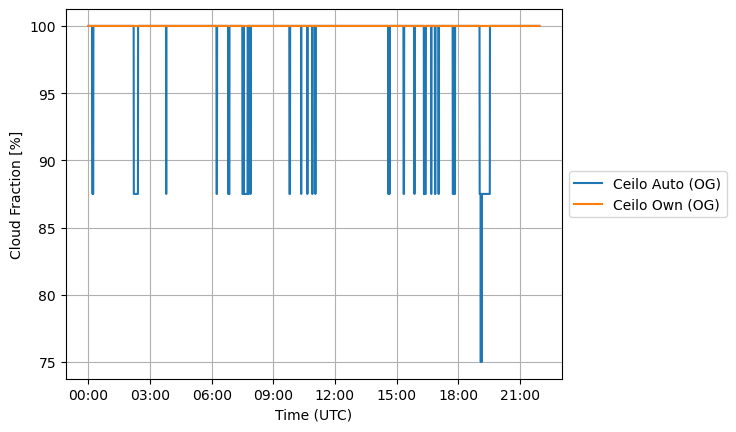

In [4]:
plt.plot(cei_data_return.time, cei_data_return.tcc_auto, label="Ceilo Auto (OG)")



#plt.plot(cei_cld_frac_basic.time, cei_cld_frac_basic, label="Ceilo Basic (RE)")
#plt.plot(cei_cld_frac_auto.time, cei_cld_frac_auto, label="Ceilo Auto (OG)")
#plt.plot(cei_cld_frac_auto_res.time, cei_cld_frac_auto_res, label="Ceilo Auto (RE)")
plt.plot(cei_data_return.time, cei_data_return.tcc_empi, label="Ceilo Own (OG)")
#plt.plot(cei_cld_frac_empi_res.time, cei_cld_frac_empi_res.tcc_empi, label="Ceilo Own (RE)")


plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
plt.xlabel("Time (UTC)")
plt.ylabel("Cloud Fraction [%]")
plt.legend(bbox_to_anchor=(1, 0.5), loc="center left")
plt.grid()